# 01 練習問題 解答 — 可逆反応 A ⇌ B
対象: [`notebooks/01_getting_started.ipynb`](../notebooks/01_getting_started.ipynb)

（掃引・複数モデルを扱うので、DSL ではなく明示 `ReactionRule` API を使う）

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species
A, B, C = (Species(x) for x in ['A','B','C'])
def R(a,b,k): return ReactionRule(a,b,k)
def reversible(kf, kr):
    mdl = NetworkModel(); mdl.add_reaction_rule(R([A],[B],kf)); mdl.add_reaction_rule(R([B],[A],kr)); return mdl

## Q1. `kf`, `kr` を変えて平衡比 $[A]/[B]=k_r/k_f$ を確かめる

In [2]:
def equil_ratio(kf, kr):
    v = run_simulation(50.0, y0={'A':60,'B':0}, model=reversible(kf,kr), solver='ode', ndiv=1, species_list=['A','B']).as_array()[-1]
    return v[1]/v[2]
print(f"{'kf':>5}{'kr':>6}{'A/B (sim)':>12}{'kr/kf (theory)':>16}")
for kf, kr in [(0.25,1.0),(1.0,1.0),(0.5,2.0),(2.0,0.5),(0.1,0.9)]:
    print(f'{kf:5.2f}{kr:6.2f}{equil_ratio(kf,kr):12.3f}{kr/kf:16.3f}')

   kf    kr   A/B (sim)  kr/kf (theory)
 0.25  1.00       4.000           4.000
 1.00  1.00       1.000           1.000
 0.50  2.00       4.000           4.000
 2.00  0.50       0.250           0.250
 0.10  0.90       9.000           9.000


**答**: シミュレーションの $[A]/[B]$ は理論値 $k_r/k_f$ と一致。平衡は正逆速度の釣り合い $k_f[A]=k_r[B]$ で決まる。

## Q2. 初期分子数を小さく（A=6）すると Gillespie の相対ノイズは?

In [3]:
mdl = reversible(0.25, 1.0)
def tail_cv(N):
    a = run_simulation(60.0, y0={'A':N,'B':0}, model=mdl, solver='gillespie', ndiv=600, species_list=['A','B'], rndseed=0).as_array()[150:,1]
    return a.mean(), a.std()/a.mean()
for N in [6, 60, 600]:
    m, cv = tail_cv(N); print(f'N={N:4d}:  <A>={m:6.1f}  CV={cv:.3f}')

N=   6:  <A>=   4.5  CV=0.201
N=  60:  <A>=  48.3  CV=0.058
N= 600:  <A>= 478.5  CV=0.017


**答**: 分子数が小さいほど**相対ノイズ CV が大きい**（CV ∝ $1/\sqrt{N}$）。N=6 は平衡値まわりで大きく揺らぎ、N=600 はほぼ滑らか。少数分子系では確率的ゆらぎが本質的（→ 02 の閾値ノイズへ）。

## Q3. `ode` / `gillespie` / `meso` を比べる

注: `meso` は `rndseed` を渡すと空間ワールドの subvolume 設定を要求するので、ここでは seed 無しで呼ぶ。

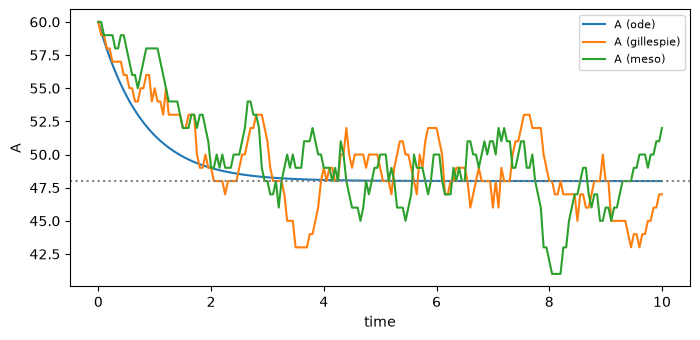

In [4]:
fig, ax = plt.subplots(figsize=(8,3.6))
for solver, c in [('ode','C0'),('gillespie','C1'),('meso','C2')]:
    a = run_simulation(10.0, y0={'A':60,'B':0}, model=mdl, solver=solver, ndiv=200, species_list=['A','B']).as_array()
    ax.plot(a[:,0], a[:,1], color=c, label=f'A ({solver})', lw=1.5)
ax.axhline(48, ls=':', c='gray'); ax.set_xlabel('time'); ax.set_ylabel('A'); ax.legend(fontsize=8); plt.show()

**答**: `ode` は滑らかな決定論解（48 収束）。`gillespie` は well-mixed 確率解でギザギザ。`meso` は空間区画に分けた確率解だが、単一区画・well-mixed 設定では Gillespie とほぼ同じ（`meso` の真価は拡散・空間勾配を入れたとき）。3者とも平均は 48:12。

## Q4. 2 分子反応 $A + B \to C$

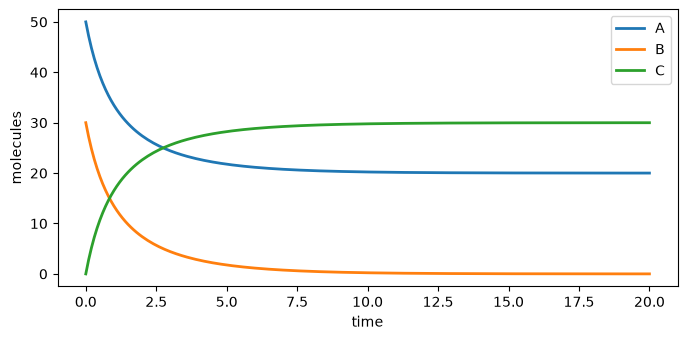

last (A,B,C) = [2.00040264e+01 4.02636216e-03 2.99959736e+01]


In [5]:
m2 = NetworkModel(); m2.add_reaction_rule(R([A,B],[C],0.02))
a = run_simulation(20.0, y0={'A':50,'B':30,'C':0}, model=m2, solver='ode', ndiv=200, species_list=['A','B','C']).as_array()
fig, ax = plt.subplots(figsize=(8,3.6))
for i,(lab,c) in enumerate([('A','C0'),('B','C1'),('C','C2')],1):
    ax.plot(a[:,0], a[:,i], color=c, label=lab, lw=2)
ax.set_xlabel('time'); ax.set_ylabel('molecules'); ax.legend(); plt.show()
print('last (A,B,C) =', a[-1][1:])

**答**: 速度 $k[A][B]$ の 2 分子反応。少ない方 B(=30) が律速で使い切られ、$C\to30$, $A\to20$, $B\to0$。1 分子反応と違い速度が**両反応物の積**に比例（質量作用の法則、02 以降の土台）。